In [1]:
import pandas as pd

In [1]:
import pandas as pd

trader = pd.read_csv("/content/historical_data.csv")
sentiment = pd.read_csv("/content/fear_greed_index.csv")

print(trader.head())
print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [2]:
print(trader.info())
print(sentiment.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [4]:

print(trader.columns)


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [5]:
trader['Timestamp'] = pd.to_datetime(trader['Timestamp'])

In [6]:
trader['Date'] = trader['Timestamp'].dt.date

In [7]:
print(sentiment.columns.tolist())

['timestamp', 'value', 'classification', 'date']


In [8]:
print(trader.head())
print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [9]:
trader['Timestamp IST'] = pd.to_datetime(
    trader['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trader['Date'] = trader['Timestamp IST'].dt.date

print(trader[['Timestamp IST','Date']].head())


        Timestamp IST        Date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02


In [10]:

sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['Date'] = sentiment['date'].dt.date

print(sentiment[['date','Date']].head())

        date        Date
0 2018-02-01  2018-02-01
1 2018-02-02  2018-02-02
2 2018-02-03  2018-02-03
3 2018-02-04  2018-02-04
4 2018-02-05  2018-02-05


In [11]:
merged = pd.merge(
    trader,
    sentiment,
    on='Date',
    how='left'
)

print(merged.shape)
print(merged.head())

(211224, 21)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0

In [12]:
print(merged['classification'].value_counts())

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [13]:
print(merged.shape)
print(merged.info())
print(merged.isnull().sum())

(211224, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64    

In [14]:
merged['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


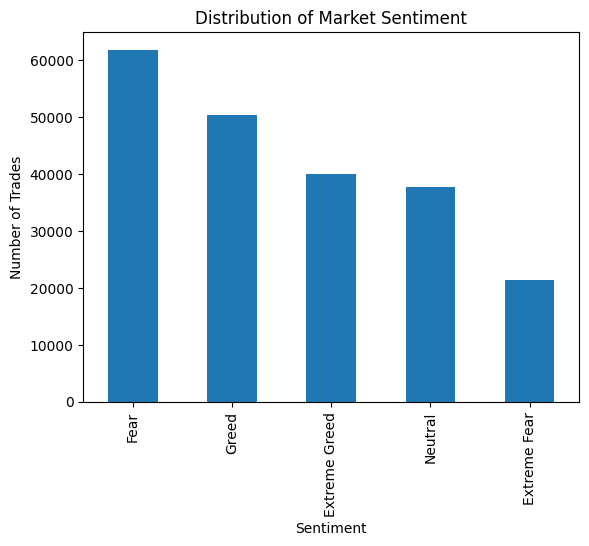

In [15]:
import matplotlib.pyplot as plt

merged['classification'].value_counts().plot(kind='bar')
plt.title('Distribution of Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')
plt.show()

Average profit


In [16]:
merged.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


Total profit


In [17]:
merged.groupby('classification')['Closed PnL'].sum()

,Closed PnL
classification,
Extreme Fear,7.391102e+05
Extreme Greed,2.715171e+06
Fear,3.357155e+06
Greed,2.150129e+06
Neutral,1.292921e+06


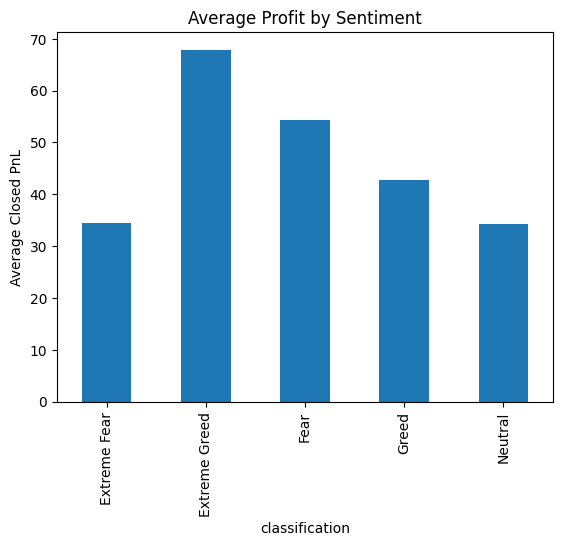

In [18]:
merged.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title('Average Profit by Sentiment')
plt.ylabel('Average Closed PnL')
plt.show()

Average Trade size


In [19]:
merged.groupby('classification')['Size USD'].mean()

,Size USD
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


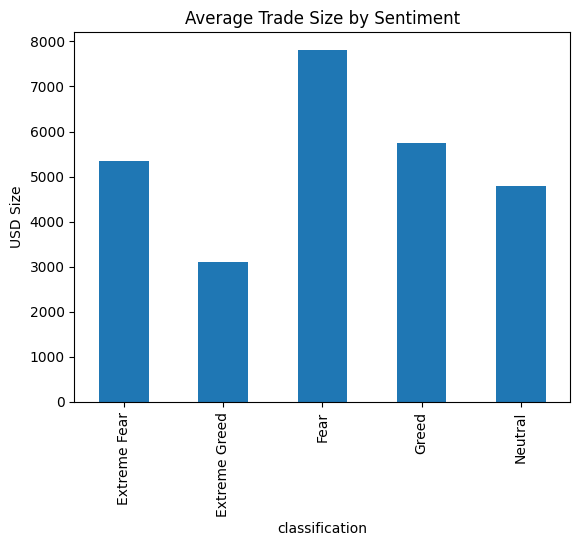

In [20]:
merged.groupby('classification')['Size USD'].mean().plot(kind='bar')
plt.title('Average Trade Size by Sentiment')
plt.ylabel('USD Size')
plt.show()

Count buy/sell trades


In [21]:
pd.crosstab(
    merged['classification'],
    merged['Side']
)

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


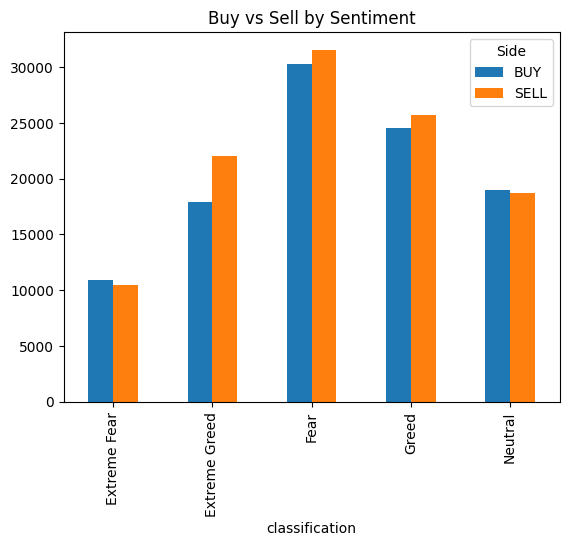

In [22]:
pd.crosstab(
    merged['classification'],
    merged['Side']
).plot(kind='bar')
plt.title('Buy vs Sell by Sentiment')
plt.show()

profit distribution


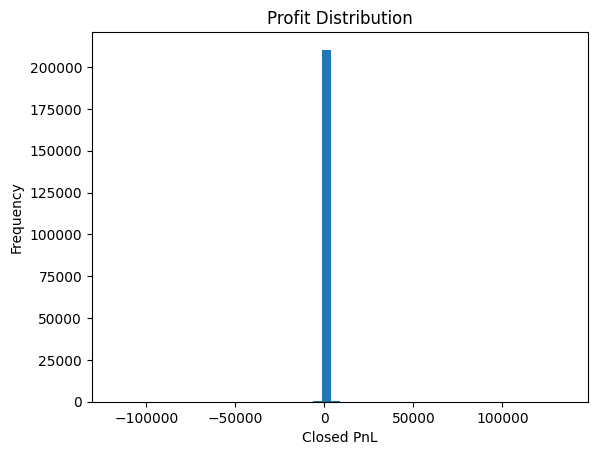

In [23]:
import matplotlib.pyplot as plt

plt.hist(merged['Closed PnL'], bins=50)
plt.title('Profit Distribution')
plt.xlabel('Closed PnL')
plt.ylabel('Frequency')
plt.show()

best and worst sentiment


In [24]:
merged.groupby('classification')['Closed PnL'].agg(
    ['mean','sum','count']
).sort_values('mean', ascending=False)

,mean,sum,count
classification,,,
Extreme Greed,67.892861,2.715171e+06,39992
Fear,54.290400,3.357155e+06,61837
Greed,42.743559,2.150129e+06,50303
Extreme Fear,34.537862,7.391102e+05,21400
Neutral,34.307718,1.292921e+06,37686


In [25]:
print(merged['classification'].value_counts())

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [26]:
print(
    merged.groupby('classification')['Closed PnL']
    .mean()
    .sort_values(ascending=False)
)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [27]:
print(
    merged.groupby('classification')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
)

classification
Fear             3.357155e+06
Extreme Greed    2.715171e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Extreme Fear     7.391102e+05
Name: Closed PnL, dtype: float64


In [29]:
print(
    merged.groupby('classification')['Size USD']
    .mean()
    .sort_values(ascending=False)
)

classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: Size USD, dtype: float64


In [30]:
print(
    pd.crosstab(
        merged['classification'],
        merged['Side']
    )
)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717
